# Crop Classification Using Sentinel-2 Time Series

Project based on the paper:
"Lightweight CNN-Transformer for Crop Mapping"

**Datasets**:
- Sentinel-2 Time Series (36 timestamps)
- USDA Cropland Data Layer (CDL)

**Regions**:
- Arkansas
- California

**Download** **libraries**

In [ ]:
!pip install rasterio
!pip install huggingface_hub
!pip install datasets
!pip install matplotlib
!pip install numpy

**LIBRARIES IMPORT**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

from huggingface_hub import snapshot_download

**LOAD DATASET FROM HUGGING FACE**

In [ ]:
from huggingface_hub import login

login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
dataset_path = snapshot_download(
    repo_id="inessal/CropMappingSentinel2",
    repo_type="dataset"
)

print("Dataset downloaded to:", dataset_path)

Fetching 45 files:   0%|          | 0/45 [00:00<?, ?it/s]

Dataset downloaded to: /root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/0e245996f63c8fd9bff6f870ae565e65f29f5884


#**PART 1**

---



In [ ]:
sentinel_arkansas = rasterio.open(dataset_path + "/Sentinel2_2021_36steps_Arkansas-0000000000-0000000000.tif")

print("Bands:", sentinel_arkansas.count)
print("Width:", sentinel_arkansas.width)
print("Height:", sentinel_arkansas.height)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

red   = sentinel_arkansas.read(4)
green = sentinel_arkansas.read(3)
blue  = sentinel_arkansas.read(2)

rgb = np.stack((red, green, blue), axis=-1).astype(float)

p2, p98 = np.percentile(rgb, (2, 98))
rgb = (rgb - p2) / (p98 - p2 + 1e-6)
rgb = np.clip(rgb, 0, 1)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("Sentinel-2 RGB")
plt.axis('off')
plt.show()

In [ ]:

red = sentinel_arkansas.read(4).astype("float32")
nir = sentinel_arkansas.read(8).astype("float32")

ndvi = (nir - red) / (nir + red + 1e-6)

print(ndvi.min(), ndvi.max())

In [ ]:

plt.figure(figsize=(6,6))

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)

plt.title("NDVI Map")
plt.colorbar(label="NDVI")

plt.show()

In [ ]:
crops = {
    "Corn":1,
    "Rice":3,
    "Soybeans":5,
    "Cotton":2
}

In [ ]:
import rasterio
import os

cdl_src = rasterio.open(cdl_ark_path)
print("CDL CRS:", cdl_src.crs)
print("CDL bounds:", cdl_src.bounds)
print("CDL shape:", cdl_src.height, cdl_src.width)
print("CDL dtype:", cdl_src.dtypes)

import numpy as np
sample_data = cdl_src.read(1)
print("\nCDL unique values (first 20):", np.unique(sample_data)[:20])
print("CDL non-zero pixels:", (sample_data > 0).sum())
print("CDL zero pixels:", (sample_data == 0).sum())

print("\n--- Sentinel Tile 0 ---")
s_src = rasterio.open(ark_tiles[0])
print("Sentinel CRS:", s_src.crs)
print("Sentinel bounds:", s_src.bounds)

print("\n--- Overlap Check ---")
print(f"CDL lon range:      [{cdl_src.bounds.left:.4f}, {cdl_src.bounds.right:.4f}]")
print(f"Sentinel lon range: [{s_src.bounds.left:.4f}, {s_src.bounds.right:.4f}]")
print(f"CDL lat range:      [{cdl_src.bounds.bottom:.4f}, {cdl_src.bounds.top:.4f}]")
print(f"Sentinel lat range: [{s_src.bounds.bottom:.4f}, {s_src.bounds.top:.4f}]")

cdl_src.close()
s_src.close()

In [ ]:
for root, dirs, files in os.walk("/"):
    for f in files:
        if 'Sentinel2_2021_36steps_Arkansas' in f:
            print(os.path.join(root, f))
            break

In [ ]:
from huggingface_hub import snapshot_download
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict


dataset_path = snapshot_download(repo_id="inessal/CropMappingSentinel2", repo_type="dataset")

label_names = {1:'Corn', 2:'Cotton', 3:'Rice', 5:'Soybeans', 99:'Others'}

TARGET = {5: 4677, 3: 2423, 1: 1522, 2: 762, 99: 616}
TOTAL_TARGET = sum(TARGET.values())  # 10000
print("Target distribution (paper Table 2):")
for k, v in TARGET.items():
    print(f"  {label_names[k]}: {v}")


t_to_wgs = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)

ark_tiles = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if 'Sentinel2_2021_36steps_Arkansas' in f and f.endswith('.tif')
])
cdl_ark_path = os.path.join(dataset_path, 'CDL_2021_Labels_Arkansas.tif')

tile_srcs = [rasterio.open(t) for t in ark_tiles]
cdl_src   = rasterio.open(cdl_ark_path)

tile_index = []
for src in tile_srcs:
    b = src.bounds
    tile_index.append({'src': src, 'left': b.left, 'right': b.right,
                       'bottom': b.bottom, 'top': b.top})

def get_tile_for_point(lon, lat):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None


VALID_CLASSES = {1, 2, 3, 5}
N_SAMPLES     = 20000
MAX_TRIES     = 1000000
RANDOM_SEED   = 42
np.random.seed(RANDOM_SEED)

cdl_bounds = cdl_src.bounds
samples_X, samples_mask, samples_y = [], [], []
samples_coords = []
class_counts = defaultdict(int)
tries = 0

print("\nSampling 20,000 points...")
while len(samples_X) < N_SAMPLES and tries < MAX_TRIES:
    tries += 1
    x = np.random.uniform(cdl_bounds.left,  cdl_bounds.right)
    y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

    label = read_cdl_pixel(x, y)
    if label is None or label == 0:
        continue

    mapped_label = label if label in VALID_CLASSES else 99
    lon, lat     = t_to_wgs.transform(x, y)
    tile         = get_tile_for_point(lon, lat)
    if tile is None:
        continue

    spectral = read_pixel(tile, lon, lat)
    if spectral is None:
        continue

    spectral_2d = spectral.reshape(36, 10).astype(np.float32)
    missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

    samples_X.append(spectral_2d.reshape(360))
    samples_mask.append(missing)
    samples_y.append(mapped_label)
    samples_coords.append((lon, lat))
    class_counts[mapped_label] += 1

    if len(samples_X) % 1000 == 0:
        print(f"  {len(samples_X)}/{N_SAMPLES} | tries: {tries} | {dict(class_counts)}")

print(f"\nRaw 20,000 distribution:")
for k, v in sorted(class_counts.items()):
    print(f"  {label_names[k]}: {v}")

X_raw      = np.array(samples_X,     dtype=np.float32)
mask_raw   = np.array(samples_mask,  dtype=np.float32)
y_raw      = np.array(samples_y,     dtype=np.int32)
coords_raw = np.array(samples_coords, dtype=np.float64)

for src in tile_srcs:
    src.close()
cdl_src.close()

print("\nApplying stratified selection...")
selected_idx = []

for cls, target_count in TARGET.items():
    cls_idx = np.where(y_raw == cls)[0]
    available = len(cls_idx)
    print(f"  {label_names[cls]:10s}: available={available}, target={target_count}", end="")

    if available >= target_count:
        chosen = np.random.choice(cls_idx, target_count, replace=False)
        print(f" → keeping {target_count} ✅")
    else:
        chosen = cls_idx
        print(f" → only {available} available ⚠️")

    selected_idx.extend(chosen.tolist())

selected_idx = np.array(selected_idx)
np.random.shuffle(selected_idx)

X_ark      = X_raw[selected_idx]
mask_ark   = mask_raw[selected_idx]
y_ark      = y_raw[selected_idx]
coords_ark = coords_raw[selected_idx]
print(f"\nFinal Arkansas shape: {X_ark.shape}")
print(f"Final Arkansas coords shape: {coords_ark.shape}")
print("Final Arkansas class distribution:")
unique, counts = np.unique(y_ark, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u):10s}: {c}")

save_dir = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)
np.save(os.path.join(save_dir, 'Arkansas_X.npy'),      X_ark)
np.save(os.path.join(save_dir, 'Arkansas_mask.npy'),   mask_ark)
np.save(os.path.join(save_dir, 'Arkansas_y.npy'),      y_ark)
np.save(os.path.join(save_dir, 'Arkansas_coords.npy'), coords_ark)  # NEW
print(f"\nSaved to {save_dir}")
print("  Arkansas_coords.npy — shape (N, 2), columns: [longitude, latitude]")

In [ ]:
import numpy as np
import os
from huggingface_hub import snapshot_download


X_path    = os.path.join(dataset_path, "Arkansas_X .npy")
mask_path = os.path.join(dataset_path, "Arkansas_mask.npy")
y_path    = os.path.join(dataset_path, "Arkansas_y.npy")

X    = np.load(X_path)
mask = np.load(mask_path)
y    = np.load(y_path)

print("\nShapes:")
print("X:", X.shape)
print("mask:", mask.shape)
print("y:", y.shape)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

X_3d = X.reshape(10000, 36, 10)

B4 = X_3d[:, :, 2].astype(np.float32)
B8 = X_3d[:, :, 6].astype(np.float32)

denom = B4 + B8
denom[denom == 0] = np.nan
NDVI = (B8 - B4) / denom

NDVI_plot = NDVI.copy()
NDVI_plot[mask == 1] = np.nan
NDVI_plot[np.isnan(denom)] = np.nan
NDVI_plot[NDVI_plot < 0] = np.nan
NDVI_plot[NDVI_plot > 1] = np.nan

doy = np.arange(1, 37) * 10
label_map = {1: 'Corn', 2: 'Cotton', 3: 'Rice', 5: 'Soybeans', 99: 'Others'}
colors = {1: 'green', 2: 'gray', 3: 'blue', 5: 'red', 99: 'orange'}
markers = {1: 'o', 2: 's', 3: '^', 5: 'D', 99: 'x'}

fig, ax = plt.subplots(figsize=(10, 4))

for cls in [1, 2, 3, 5, 99]:
    idx = (y == cls)
    ndvi_cls = NDVI_plot[idx]

    mean_ndvi = np.nanmean(ndvi_cls, axis=0)

    nans = np.isnan(mean_ndvi)
    x_idx = np.arange(36)
    if nans.sum() < 36:
        mean_ndvi[nans] = np.interp(
            x_idx[nans],
            x_idx[~nans],
            mean_ndvi[~nans]
        )

    mean_ndvi = np.clip(mean_ndvi, 0, 1)
    mean_ndvi = savgol_filter(mean_ndvi, window_length=7, polyorder=2)
    mean_ndvi = np.clip(mean_ndvi, 0, 1)

    ax.plot(doy, mean_ndvi,
            label=label_map[cls],
            color=colors[cls],
            marker=markers[cls],
            markersize=4,
            linewidth=1.5)

ax.set_xlabel('Day of Year')
ax.set_ylabel('Mean NDVI Value')
ax.set_title('(a) Arkansas')
ax.legend(loc='upper left')
ax.set_ylim(0, 1)
ax.set_xlim(0, 370)
ax.set_xticks([10, 60, 110, 160, 210, 260, 310, 360])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from huggingface_hub import snapshot_download
import os
import numpy as np


X = np.load(os.path.join(dataset_path, "Arkansas_X .npy"))
y = np.load(os.path.join(dataset_path, "Arkansas_y.npy"))
mask = np.load(os.path.join(dataset_path, "Arkansas_mask.npy"))

print("\n✅ Shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("mask:", mask.shape)

unique, counts = np.unique(y, return_counts=True)

print("\n Samples per class:\n")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

label_map = {
    1: "Corn ",
    2: "Cotton",
    3: "Rice ",
    5: "Soybeans",
    99: "Others "
}

print("\n Class meaning:\n")
for u, c in zip(unique, counts):
    name = label_map.get(u, "Unknown")
    print(f"Class {u} ({name}): {c}")

print("\n Total samples:", len(y))

if len(y) == 10000:
    print(" Total matches paper (10000)")
else:
    print(" Total is incorrect")

missing = np.sum(mask == 0)
valid = np.sum(mask == 1)

print("\n Mask stats:")
print("Missing values:", missing)
print("Valid values:", valid)

ratio = valid / (valid + missing)
print(f"Valid ratio: {ratio:.2f}")

**CALIFORNIA**

In [ ]:
from huggingface_hub import snapshot_download
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict

dataset_path = snapshot_download(
    repo_id="inessal/CropMappingSentinel2",
    repo_type="dataset"
)

t_to_wgs = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)

label_names = {69:'Grapes', 3:'Rice', 36:'Alfalfa',
               75:'Almonds', 204:'Pistachios', 99:'Others'}

PAPER_TARGETS = {
    69:  2054,
    3:   2037,
    36:   974,
    75:   783,
    204:  640,
    99:  3512,
}

AREA1_TARGETS = {
    3:   2037,
    36:   974,
    69:  1027,
    99:  1756,
}
AREA2_TARGETS = {
    204:  640,
    75:   783,
    69:  1027,
    99:  1756,
}


def build_tile_index(tiles):
    srcs = [rasterio.open(t) for t in tiles]
    index = []
    for src in srcs:
        b = src.bounds
        index.append({'src': src, 'left': b.left, 'right': b.right,
                      'bottom': b.bottom, 'top': b.top})
    return srcs, index

def get_tile_for_point(lon, lat, tile_index):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(cdl_src, x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None

def map_label(label):
    if label in {69, 3, 75, 204}:
        return label
    elif label in {36, 37}:
        return 36
    else:
        return 99

def sample_area(sentinel_tiles, cdl_path, targets,
                max_tries=5_000_000, seed=42):
    tile_srcs, tile_index = build_tile_index(sentinel_tiles)
    cdl_src    = rasterio.open(cdl_path)
    cdl_bounds = cdl_src.bounds

    np.random.seed(seed)
    active = {cls for cls, n in targets.items() if n > 0}

    collected = defaultdict(int)
    all_X, all_mask, all_y = [], [], []
    tries = 0

    print(f"  Targets: {dict(targets)}")
    print(f"  CDL bounds: {cdl_bounds}")

    while tries < max_tries:
        tries += 1

        if all(collected[cls] >= targets[cls] for cls in active):
            print(f"  All targets reached in {tries:,} tries!")
            break

        x = np.random.uniform(cdl_bounds.left, cdl_bounds.right)
        y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

        label = read_cdl_pixel(cdl_src, x, y)
        if label is None or label == 0:
            continue

        mapped = map_label(label)

        if mapped not in active:
            continue
        if collected[mapped] >= targets[mapped]:
            continue

        lon, lat = t_to_wgs.transform(x, y)
        tile     = get_tile_for_point(lon, lat, tile_index)
        if tile is None:
            continue

        spectral = read_pixel(tile, lon, lat)
        if spectral is None:
            continue

        spectral_2d = spectral.reshape(36, 10).astype(np.float32)
        missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

        all_X.append(spectral_2d.reshape(360))
        all_mask.append(missing)
        all_y.append(mapped)
        collected[mapped] += 1

        if tries % 100_000 == 0:
            print(f"  tries: {tries:,} | {dict(collected)}")

    print(f"\n  Final after {tries:,} tries:")
    for cls in sorted(collected.keys()):
        name   = label_names.get(cls, str(cls))
        got    = collected[cls]
        target = targets.get(cls, 0)
        status = '✅' if got >= target else f'⚠️  only {got}'
        print(f"    {name:12s}: {got}/{target} {status}")

    for src in tile_srcs:
        src.close()
    cdl_src.close()

    return (np.array(all_X,    dtype=np.float32),
            np.array(all_mask, dtype=np.float32),
            np.array(all_y,    dtype=np.int32))


files = os.listdir(dataset_path)

area1_tiles = sorted([
    os.path.join(dataset_path, f) for f in files
    if 'California_Area1' in f and f.endswith('.tif') and 'CDL' not in f
])
area2_tiles = sorted([
    os.path.join(dataset_path, f) for f in files
    if 'California_Area2' in f and f.endswith('.tif') and 'CDL' not in f
])
cdl_area1 = os.path.join(dataset_path, 'CDL_2021_Labels_California_Area1.tif')
cdl_area2 = os.path.join(dataset_path, 'CDL_2021_Labels_California_Area2.tif')

print(f"Area1 tiles:      {len(area1_tiles)}")
print(f"Area2 tiles:      {len(area2_tiles)}")
print(f"CDL Area1 exists: {os.path.exists(cdl_area1)}")
print(f"CDL Area2 exists: {os.path.exists(cdl_area2)}")


print("\n=== Sampling Area 1 ===")
X1, mask1, y1 = sample_area(
    area1_tiles, cdl_area1, AREA1_TARGETS,
    max_tries=5_000_000, seed=42
)

print("\n=== Sampling Area 2 (San Joaquin -119.7, 36.6) ===")
X2, mask2, y2 = sample_area(
    area2_tiles, cdl_area2, AREA2_TARGETS,
    max_tries=5_000_000, seed=123
)


print("\n=== Merging ===")
X_cal    = np.concatenate([X1, X2],       axis=0)
mask_cal = np.concatenate([mask1, mask2], axis=0)
y_cal    = np.concatenate([y1, y2],       axis=0)

idx      = np.random.RandomState(42).permutation(len(X_cal))
X_cal    = X_cal[idx]
mask_cal = mask_cal[idx]
y_cal    = y_cal[idx]

print(f"Final shape: {X_cal.shape}")
print("\nFinal class distribution:")
unique, counts = np.unique(y_cal, return_counts=True)
for u, c in zip(unique, counts):
    name   = label_names.get(int(u), str(u))
    target = PAPER_TARGETS.get(int(u), '?')
    print(f"  {name:12s}: {c:5d} (target: {target})")
print(f"  Total: {len(y_cal)}")


save_dir = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)
np.save(os.path.join(save_dir, 'California_X.npy'),    X_cal)
np.save(os.path.join(save_dir, 'California_mask.npy'), mask_cal)
np.save(os.path.join(save_dir, 'California_y.npy'),    y_cal)
print(f"\nSaved to {save_dir}")

In [ ]:
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(repo_id="inessal/CropMappingSentinel2", repo_type="dataset")
save_dir     = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)

label_names = {69:'Grapes', 75:'Almonds', 204:'Pistachios',
               3:'Rice',    36:'Alfalfa',  99:'Others'}

def build_tile_index(tiles):
    srcs = [rasterio.open(t) for t in tiles]
    index = []
    for src in srcs:
        b = src.bounds
        index.append({'src': src, 'left': b.left, 'right': b.right,
                      'bottom': b.bottom, 'top': b.top})
    return srcs, index

def get_tile_for_point(lon, lat, tile_index):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(cdl_src, x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None

def sample_area(sentinel_tiles, cdl_path, valid_classes,
                n_samples, max_tries=2000000, seed=42):
    t_to_wgs   = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)
    tile_srcs, tile_index = build_tile_index(sentinel_tiles)
    cdl_src    = rasterio.open(cdl_path)
    cdl_bounds = cdl_src.bounds

    np.random.seed(seed)
    samples_X, samples_mask, samples_y = [], [], []
    class_counts = defaultdict(int)
    tries = 0

    while len(samples_X) < n_samples and tries < max_tries:
        tries += 1
        x = np.random.uniform(cdl_bounds.left,  cdl_bounds.right)
        y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

        label = read_cdl_pixel(cdl_src, x, y)
        if label is None or label == 0:
            continue

        mapped_label = label if label in valid_classes else 99
        lon, lat     = t_to_wgs.transform(x, y)
        tile         = get_tile_for_point(lon, lat, tile_index)
        if tile is None:
            continue

        spectral = read_pixel(tile, lon, lat)
        if spectral is None:
            continue

        spectral_2d = spectral.reshape(36, 10).astype(np.float32)
        missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

        samples_X.append(spectral_2d.reshape(360))
        samples_mask.append(missing)
        samples_y.append(mapped_label)
        class_counts[mapped_label] += 1

        if len(samples_X) % 500 == 0:
            print(f"  {len(samples_X)}/{n_samples} | tries: {tries} | {dict(class_counts)}")

    for src in tile_srcs:
        src.close()
    cdl_src.close()

    return (np.array(samples_X,    dtype=np.float32),
            np.array(samples_mask, dtype=np.float32),
            np.array(samples_y,    dtype=np.int32),
            class_counts)

def safe_sample(idx, n):
    return np.random.choice(idx, min(n, len(idx)), replace=False)

print("Setup done ✓")

In [ ]:
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(repo_id="inessal/CropMappingSentinel2", repo_type="dataset")
save_dir     = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)

label_names = {69:'Grapes', 75:'Almonds', 204:'Pistachios',
               3:'Rice',    36:'Alfalfa',  99:'Others'}

def build_tile_index(tiles):
    srcs = [rasterio.open(t) for t in tiles]
    index = []
    for src in srcs:
        b = src.bounds
        index.append({'src': src, 'left': b.left, 'right': b.right,
                      'bottom': b.bottom, 'top': b.top})
    return srcs, index

def get_tile_for_point(lon, lat, tile_index):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(cdl_src, x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None

def sample_area(sentinel_tiles, cdl_path, valid_classes,
                n_samples, max_tries=2000000, seed=42):
    t_to_wgs   = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)
    tile_srcs, tile_index = build_tile_index(sentinel_tiles)
    cdl_src    = rasterio.open(cdl_path)
    cdl_bounds = cdl_src.bounds

    np.random.seed(seed)
    samples_X, samples_mask, samples_y = [], [], []
    class_counts = defaultdict(int)
    tries = 0

    while len(samples_X) < n_samples and tries < max_tries:
        tries += 1
        x = np.random.uniform(cdl_bounds.left,  cdl_bounds.right)
        y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

        label = read_cdl_pixel(cdl_src, x, y)
        if label is None or label == 0:
            continue

        mapped_label = label if label in valid_classes else 99
        lon, lat     = t_to_wgs.transform(x, y)
        tile         = get_tile_for_point(lon, lat, tile_index)
        if tile is None:
            continue

        spectral = read_pixel(tile, lon, lat)
        if spectral is None:
            continue

        spectral_2d = spectral.reshape(36, 10).astype(np.float32)
        missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

        samples_X.append(spectral_2d.reshape(360))
        samples_mask.append(missing)
        samples_y.append(mapped_label)
        class_counts[mapped_label] += 1

        if len(samples_X) % 500 == 0:
            print(f"  {len(samples_X)}/{n_samples} | tries: {tries} | {dict(class_counts)}")

    for src in tile_srcs:
        src.close()
    cdl_src.close()

    return (np.array(samples_X,    dtype=np.float32),
            np.array(samples_mask, dtype=np.float32),
            np.array(samples_y,    dtype=np.int32),
            class_counts)

def safe_sample(idx, n):
    return np.random.choice(idx, min(n, len(idx)), replace=False)

print("Setup done ✓")

In [ ]:
import numpy as np
from huggingface_hub import hf_hub_download

REPO_ID = "inessal/CropMappingSentinel2"

mask_ark = np.load(hf_hub_download(REPO_ID, "Arkansas_mask.npy", repo_type="dataset"))
mask_cal = np.load(hf_hub_download(REPO_ID, "California_mask.npy", repo_type="dataset"))

print("=== Missing Rate ===")
print(f"Arkansas:   {mask_ark.mean()*100:.2f}% of timesteps missing")
print(f"California: {mask_cal.mean()*100:.2f}% of timesteps missing")

print("\n=== Per timestep missing rate (Arkansas) ===")
doy = np.arange(1, 37) * 10
for i, (d, r) in enumerate(zip(doy, mask_ark.mean(axis=0)*100)):
    bar = '█' * int(r/2)
    print(f"  DOY {d:3d}: {r:5.1f}% {bar}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

doy = np.arange(1, 37) * 10

# Arkansas
axes[0].bar(doy, mask_ark.mean(axis=0) * 100,
            color='steelblue', width=8, alpha=0.7)
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Missing Rate (%)')
axes[0].set_title('(a) Arkansas — Missing Data per Timestep\n'
                  f'Overall: {mask_ark.mean()*100:.1f}% missing')
axes[0].set_ylim(0, 105)
axes[0].axhline(y=mask_ark.mean()*100, color='red',
                linestyle='--', label=f'Mean: {mask_ark.mean()*100:.1f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# California
axes[1].bar(doy, mask_cal.mean(axis=0) * 100,
            color='darkorange', width=8, alpha=0.7)
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('Missing Rate (%)')
axes[1].set_title('(b) California — Missing Data per Timestep\n'
                  f'Overall: {mask_cal.mean()*100:.1f}% missing')
axes[1].set_ylim(0, 105)
axes[1].axhline(y=mask_cal.mean()*100, color='red',
                linestyle='--', label=f'Mean: {mask_cal.mean()*100:.1f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('missing_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key findings:")
print(f"  Arkansas completely clouded timesteps: "
      f"{(mask_ark.mean(axis=0)==1).sum()} out of 36")
print(f"  California completely clouded timesteps: "
      f"{(mask_cal.mean(axis=0)==1).sum()} out of 36")
print(f"  Arkansas clear timesteps (0% missing): "
      f"{(mask_ark.mean(axis=0)==0).sum()} out of 36")
print(f"  California clear timesteps (0% missing): "
      f"{(mask_cal.mean(axis=0)==0).sum()} out of 36")

# **PART 2 CREATING MODEL**

**Split train val test**

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import hf_hub_download

REPO_ID = "inessal/CropMappingSentinel2"
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

print("\nLoading data from HuggingFace...")
X_ark    = np.load(hf_hub_download(REPO_ID, "Arkansas_X.npy",       repo_type="dataset"))
mask_ark = np.load(hf_hub_download(REPO_ID, "Arkansas_mask.npy",    repo_type="dataset"))
y_ark    = np.load(hf_hub_download(REPO_ID, "Arkansas_y.npy",       repo_type="dataset"))
X_cal    = np.load(hf_hub_download(REPO_ID, "California_X.npy",     repo_type="dataset"))
mask_cal = np.load(hf_hub_download(REPO_ID, "California_mask.npy",  repo_type="dataset"))
y_cal    = np.load(hf_hub_download(REPO_ID, "California_y.npy",     repo_type="dataset"))
print("Data loaded")

X_ark = X_ark / 10000.0
X_cal = X_cal / 10000.0
print("Normalized")

X_ark = X_ark.reshape(-1, 36, 10)
X_cal = X_cal.reshape(-1, 36, 10)

def stratified_split(X, mask, y, n_train=240, n_val=60, seed=42):
    np.random.seed(seed)
    classes = np.unique(y)
    train_idx, val_idx, test_idx = [], [], []
    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        np.random.shuffle(cls_idx)
        if len(cls_idx) < n_train + n_val:
            n_tr = int(len(cls_idx) * 0.8)
            n_vl = len(cls_idx) - n_tr
            train_idx.extend(cls_idx[:n_tr].tolist())
            val_idx.extend(cls_idx[n_tr:n_tr+n_vl].tolist())
        else:
            train_idx.extend(cls_idx[:n_train].tolist())
            val_idx.extend(cls_idx[n_train:n_train+n_val].tolist())
            test_idx.extend(cls_idx[n_train+n_val:].tolist())
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)
    np.random.shuffle(test_idx)
    return (X[train_idx],    mask[train_idx],    y[train_idx],
            X[val_idx],      mask[val_idx],      y[val_idx],
            X[test_idx],     mask[test_idx],     y[test_idx])

(X_ark_train, mask_ark_train, y_ark_train,
 X_ark_val,   mask_ark_val,   y_ark_val,
 X_ark_test,  mask_ark_test,  y_ark_test) = stratified_split(X_ark, mask_ark, y_ark)

(X_cal_train, mask_cal_train, y_cal_train,
 X_cal_val,   mask_cal_val,   y_cal_val,
 X_cal_test,  mask_cal_test,  y_cal_test) = stratified_split(X_cal, mask_cal, y_cal)

print("✅ Split done")
print(f"   Arkansas  — Train: {len(y_ark_train)}, Val: {len(y_ark_val)}, Test: {len(y_ark_test)}")
print(f"   California — Train: {len(y_cal_train)}, Val: {len(y_cal_val)}, Test: {len(y_cal_test)}")

class CropDataset(Dataset):
    def __init__(self, X, mask, y, label_map):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y    = torch.tensor(
                        np.array([label_map[int(c)] for c in y]),
                        dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

ark_label_map  = {1:0, 2:1, 3:2, 5:3, 99:4}
cal_label_map  = {69:0, 3:1, 36:2, 75:3, 204:4, 99:5}
ark_class_names = ['Corn', 'Cotton', 'Rice', 'Soybeans', 'Others']
cal_class_names = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

BATCH_SIZE = 32

ark_train_loader = DataLoader(CropDataset(X_ark_train, mask_ark_train, y_ark_train, ark_label_map), batch_size=BATCH_SIZE, shuffle=True)
ark_val_loader   = DataLoader(CropDataset(X_ark_val,   mask_ark_val,   y_ark_val,   ark_label_map), batch_size=BATCH_SIZE, shuffle=False)
ark_test_loader  = DataLoader(CropDataset(X_ark_test,  mask_ark_test,  y_ark_test,  ark_label_map), batch_size=BATCH_SIZE, shuffle=False)

cal_train_loader = DataLoader(CropDataset(X_cal_train, mask_cal_train, y_cal_train, cal_label_map), batch_size=BATCH_SIZE, shuffle=True)
cal_val_loader   = DataLoader(CropDataset(X_cal_val,   mask_cal_val,   y_cal_val,   cal_label_map), batch_size=BATCH_SIZE, shuffle=False)
cal_test_loader  = DataLoader(CropDataset(X_cal_test,  mask_cal_test,  y_cal_test,  cal_label_map), batch_size=BATCH_SIZE, shuffle=False)

print("✅ DataLoaders ready")

X_b, mask_b, y_b = next(iter(ark_train_loader))
print(f"\nSample batch — X: {X_b.shape}, mask: {mask_b.shape}, y: {y_b.shape}")
print(f"Device: {DEVICE}")
print("\nReady to build and train MCTNet!")

Using device: cpu

Loading data from HuggingFace...
Data loaded
Normalized
✅ Split done
   Arkansas  — Train: 1200, Val: 300, Test: 8500
   California — Train: 1440, Val: 360, Test: 8200
✅ DataLoaders ready

Sample batch — X: torch.Size([32, 36, 10]), mask: torch.Size([32, 36]), y: torch.Size([32])
Device: cpu

Ready to build and train MCTNet!


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import warnings
warnings.filterwarnings('ignore')


class ALPE(nn.Module):
    def __init__(self, d=10, T=36):
        super().__init__()
        pe = torch.zeros(T, d)
        pos = torch.arange(T).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-np.log(10000) / d))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer('pe', pe)

        self.conv = nn.Conv1d(d, d, kernel_size=3, padding=1)

        self.eca = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(d, d, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x, mask):
        pe = self.pe.unsqueeze(0).expand(x.size(0), -1, -1)

        pe = pe * (1 - mask.unsqueeze(-1))

        pe = pe.transpose(1, 2)
        pe = self.conv(pe)

        scale = self.eca(pe)
        pe = pe * scale

        return pe.transpose(1, 2)



class CNNBlock(nn.Module):
    def __init__(self, d, k=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d),
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        xt = x.transpose(1, 2)
        out = self.net(xt)
        return self.relu(out + xt).transpose(1, 2)



class CTFusion(nn.Module):
    def __init__(self, d, n_head, k=3, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe

        if use_alpe:
            self.alpe = ALPE(d=d)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d,
            nhead           = n_head,
            dim_feedforward = d * 8,
            batch_first     = True,
            dropout         = 0.1
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.cnn  = CNNBlock(d, k)

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            pos = self.alpe(x, mask)
            xt  = x + pos
        else:
            xt = x

        t_out = self.transformer(xt)

        c_out = self.cnn(xt)

        fused = torch.cat([t_out, c_out], dim=-1)

        out = self.pool(fused.transpose(1, 2))

        return out.transpose(1, 2)


class MCTNet(nn.Module):
    def __init__(self, n_bands=10, n_stages=3,
                 n_head=5, kernel_size=3, n_classes=5):
        super().__init__()

        self.stages = nn.ModuleList()
        in_d = n_bands

        for i in range(n_stages):
            self.stages.append(
                CTFusion(
                    d        = in_d,
                    n_head   = n_head,
                    k        = kernel_size,
                    use_alpe = (i == 0)
                )
            )
            in_d *= 2
        self.classifier = nn.Linear(in_d, n_classes)

    def forward(self, x, mask=None):
        for stage in self.stages:
            x = stage(x, mask)

        x = x.max(dim=1).values

        return self.classifier(x)



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_ark = MCTNet(n_classes=5).to(device)
model_cal = MCTNet(n_classes=6).to(device)

x_test    = torch.randn(32, 36, 10).to(device)
mask_test = torch.zeros(32, 36).to(device)
mask_test[:, 5:8] = 1

out_ark = model_ark(x_test, mask_test)
out_cal = model_cal(x_test, mask_test)

print(f"Output (Arkansas):    {out_ark.shape}")
print(f"Output (California):  {out_cal.shape}")
print(f"Parameters:           {sum(p.numel() for p in model_ark.parameters()):,}")
print("\nModel ready for training!")

Device: cpu
Output (Arkansas):    torch.Size([32, 5])
Output (California):  torch.Size([32, 6])
Parameters:           57,035
Paper:                ~55,059

✅ Model ready for training!



Training MCTNet on Arkansas
  lr=0.001, weight_decay=0.0001, patience=10
 Epoch | Train Loss |  Train OA |  Val Loss |  Val OA | Val Kappa |  Val F1
----------------------------------------------------------------------
     1 |     1.0930 |    0.6233 |    0.9734 |  0.6767 |    0.5958 |  0.6896 ← best
    10 |     0.1490 |    0.9517 |    0.1645 |  0.9400 |    0.9250 |  0.9391
    20 |     0.0842 |    0.9692 |    0.1870 |  0.9367 |    0.9208 |  0.9369
    30 |     0.0167 |    0.9967 |    0.1638 |  0.9533 |    0.9417 |  0.9535
    40 |     0.0080 |    1.0000 |    0.1625 |  0.9533 |    0.9417 |  0.9534

⏹ Early stopping at epoch 45 (no improvement for 10 epochs)

✅ Best model at epoch 35 with Val Kappa = 0.9667

FINAL TEST RESULTS — Arkansas
  OA:    0.9514   (paper: 0.968)
  Kappa: 0.9266   (paper: 0.951)
  F1:    0.9162   (paper: 0.933)


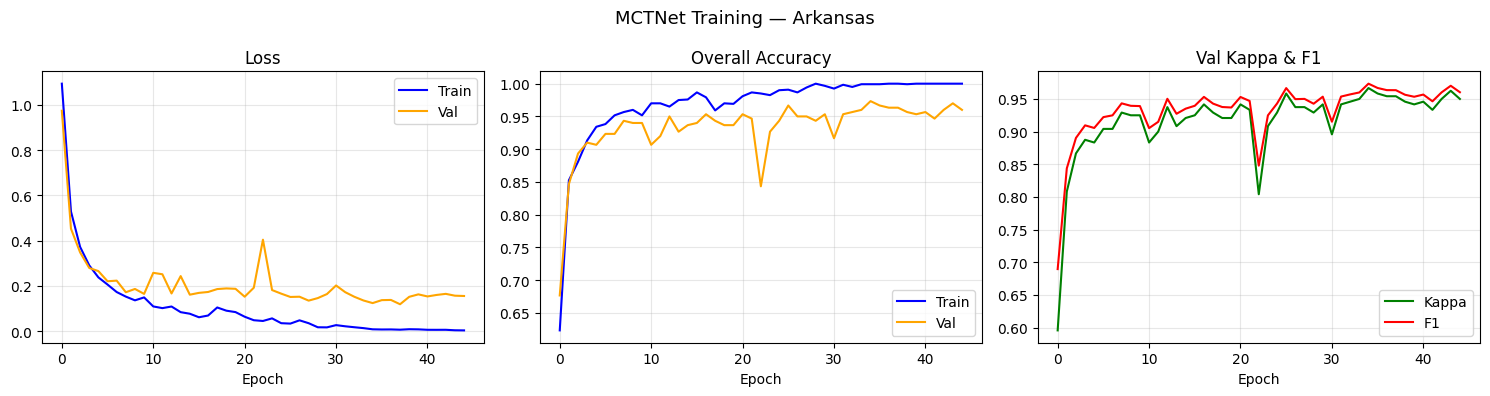

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import cohen_kappa_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, mask_batch, y_batch in loader:
        X_batch    = X_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch    = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch, mask_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, mask_batch, y_batch in loader:
            X_batch    = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch    = y_batch.to(device)

            outputs = model(X_batch, mask_batch)
            loss    = criterion(outputs, y_batch)

            total_loss += loss.item() * len(y_batch)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / total
    oa       = correct / total
    kappa    = cohen_kappa_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)

    return avg_loss, oa, kappa, f1



def train_model(model, train_loader, val_loader,
                n_epochs=200, lr=0.001,
                weight_decay=1e-4,
                patience=20,
                device='cuda',
                state_name='Arkansas'):

    criterion = nn.CrossEntropyLoss()

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_kappa  = 0.0
    best_epoch      = 0
    best_weights    = None
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'val_loss':  [],
        'train_oa':   [], 'val_oa':    [],
        'val_kappa':  [], 'val_f1':    []
    }

    print(f"\n{'='*70}")
    print(f"Training MCTNet on {state_name}")
    print(f"  lr={lr}, weight_decay={weight_decay}, patience={patience}")
    print(f"{'='*70}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train OA':>9} | "
          f"{'Val Loss':>9} | {'Val OA':>7} | {'Val Kappa':>9} | {'Val F1':>7}")
    print(f"{'-'*70}")

    for epoch in range(1, n_epochs + 1):

        train_loss, train_oa = train_one_epoch(
            model, train_loader, optimizer, criterion, device)

        val_loss, val_oa, val_kappa, val_f1 = evaluate(
            model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_oa'].append(train_oa)
        history['val_oa'].append(val_oa)
        history['val_kappa'].append(val_kappa)
        history['val_f1'].append(val_f1)

        if val_kappa > best_val_kappa:
            best_val_kappa    = val_kappa
            best_epoch        = epoch
            best_weights      = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            marker = ' ← best' if epoch == best_epoch else ''
            print(f"{epoch:>6} | {train_loss:>10.4f} | {train_oa:>9.4f} | "
                  f"{val_loss:>9.4f} | {val_oa:>7.4f} | "
                  f"{val_kappa:>9.4f} | {val_f1:>7.4f}{marker}")

        if epochs_no_improve >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    print(f"\n Best model at epoch {best_epoch} "
          f"with Val Kappa = {best_val_kappa:.4f}")

    model.load_state_dict({k: v.to(device)
                           for k, v in best_weights.items()})

    return model, history


def plot_history(history, state_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history['train_loss'], label='Train', color='blue')
    axes[0].plot(history['val_loss'],   label='Val',   color='orange')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_oa'], label='Train', color='blue')
    axes[1].plot(history['val_oa'],   label='Val',   color='orange')
    axes[1].set_title('Overall Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(history['val_kappa'], label='Kappa', color='green')
    axes[2].plot(history['val_f1'],    label='F1',    color='red')
    axes[2].set_title('Val Kappa & F1')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'MCTNet Training — {state_name}', fontsize=13)
    plt.tight_layout()
    plt.show()


device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ark = MCTNet(n_classes=5).to(device)

model_ark, history_ark = train_model(
    model        = model_ark,
    train_loader = ark_train_loader,
    val_loader   = ark_val_loader,
    n_epochs     = 200,
    lr           = 0.001,
    weight_decay = 1e-4,
    patience     = 10,
    device       = device,
    state_name   = 'Arkansas'
)

print("\n" + "="*60)
print("FINAL TEST RESULTS — Arkansas")
print("="*60)
_, test_oa, test_kappa, test_f1 = evaluate(
    model_ark, ark_test_loader, nn.CrossEntropyLoss(), device)
print(f"  OA:    {test_oa:.4f}   (paper: 0.968)")
print(f"  Kappa: {test_kappa:.4f}   (paper: 0.951)")
print(f"  F1:    {test_f1:.4f}   (paper: 0.933)")

plot_history(history_ark, 'Arkansas')



Training MCTNet on California
  lr=0.001, weight_decay=0.001, patience=10
 Epoch | Train Loss |  Train OA |  Val Loss |  Val OA | Val Kappa |  Val F1
----------------------------------------------------------------------
     1 |     0.9916 |    0.6576 |    0.7513 |  0.7528 |    0.7033 |  0.7345 ← best
    10 |     0.2811 |    0.9083 |    0.3823 |  0.8861 |    0.8633 |  0.8873 ← best
    20 |     0.1774 |    0.9514 |    0.3374 |  0.8944 |    0.8733 |  0.8934

⏹ Early stopping at epoch 21 (no improvement for 10 epochs)

✅ Best model at epoch 11 with Val Kappa = 0.8733

FINAL TEST RESULTS — California
  OA:    0.8470   (paper: 0.852)
  Kappa: 0.7993   (paper: 0.806)
  F1:    0.8149   (paper: 0.829)


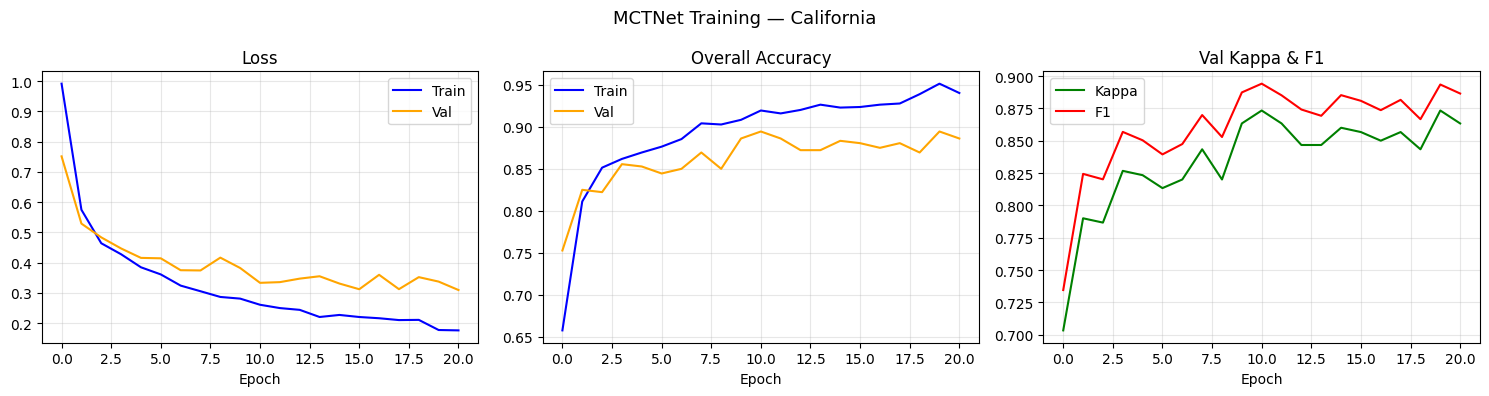

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import cohen_kappa_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, mask_batch, y_batch in loader:
        X_batch    = X_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch    = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch, mask_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, mask_batch, y_batch in loader:
            X_batch    = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch    = y_batch.to(device)

            outputs = model(X_batch, mask_batch)
            loss    = criterion(outputs, y_batch)

            total_loss += loss.item() * len(y_batch)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / total
    oa       = correct / total
    kappa    = cohen_kappa_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)

    return avg_loss, oa, kappa, f1


def train_model(model, train_loader, val_loader,
                n_epochs=200, lr=0.001,
                weight_decay=1e-4,
                patience=15,          # early stopping patience
                device='cuda',
                state_name='California'):

    criterion = nn.CrossEntropyLoss()

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_kappa  = 0.0
    best_epoch      = 0
    best_weights    = None
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'val_loss':  [],
        'train_oa':   [], 'val_oa':    [],
        'val_kappa':  [], 'val_f1':    []
    }

    print(f"\n{'='*70}")
    print(f"Training MCTNet on {state_name}")
    print(f"  lr={lr}, weight_decay={weight_decay}, patience={patience}")
    print(f"{'='*70}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train OA':>9} | "
          f"{'Val Loss':>9} | {'Val OA':>7} | {'Val Kappa':>9} | {'Val F1':>7}")
    print(f"{'-'*70}")

    for epoch in range(1, n_epochs + 1):

        train_loss, train_oa = train_one_epoch(
            model, train_loader, optimizer, criterion, device)

        val_loss, val_oa, val_kappa, val_f1 = evaluate(
            model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_oa'].append(train_oa)
        history['val_oa'].append(val_oa)
        history['val_kappa'].append(val_kappa)
        history['val_f1'].append(val_f1)

        if val_kappa > best_val_kappa:
            best_val_kappa    = val_kappa
            best_epoch        = epoch
            best_weights      = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epoch % 10 == 0 or epoch == 1:
            marker = ' ← best' if epoch == best_epoch else ''
            print(f"{epoch:>6} | {train_loss:>10.4f} | {train_oa:>9.4f} | "
                  f"{val_loss:>9.4f} | {val_oa:>7.4f} | "
                  f"{val_kappa:>9.4f} | {val_f1:>7.4f}{marker}")

        if epochs_no_improve >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    print(f"\n✅ Best model at epoch {best_epoch} "
          f"with Val Kappa = {best_val_kappa:.4f}")

    model.load_state_dict({k: v.to(device)
                           for k, v in best_weights.items()})

    return model, history


def plot_history(history, state_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history['train_loss'], label='Train', color='blue')
    axes[0].plot(history['val_loss'],   label='Val',   color='orange')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_oa'], label='Train', color='blue')
    axes[1].plot(history['val_oa'],   label='Val',   color='orange')
    axes[1].set_title('Overall Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(history['val_kappa'], label='Kappa', color='green')
    axes[2].plot(history['val_f1'],    label='F1',    color='red')
    axes[2].set_title('Val Kappa & F1')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'MCTNet Training — {state_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

model_cal = MCTNet(n_classes=6).to(device)

model_cal, history_cal = train_model(
    model        = model_cal,
    train_loader = cal_train_loader,
    val_loader   = cal_val_loader,
    n_epochs     = 200,
    lr           = 0.001,
    weight_decay = 1e-3,
    patience     = 10,
    device       = device,
    state_name   = 'California'
)

print("\n" + "="*60)
print("FINAL TEST RESULTS — California")
print("="*60)
_, test_oa, test_kappa, test_f1 = evaluate(
    model_cal, cal_test_loader, nn.CrossEntropyLoss(), device)
print(f"  OA:    {test_oa:.4f}   (paper: 0.852)")
print(f"  Kappa: {test_kappa:.4f}   (paper: 0.806)")
print(f"  F1:    {test_f1:.4f}   (paper: 0.829)")

plot_history(history_cal, 'California')

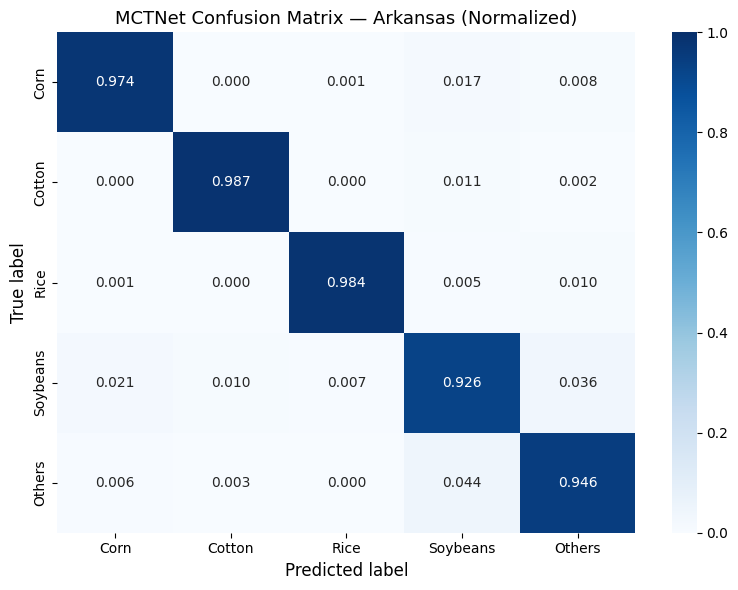


Per-Class Results — Arkansas
              precision    recall  f1-score   support

        Corn     0.9232    0.9738    0.9478      1222
      Cotton     0.9120    0.9870    0.9480       462
        Rice     0.9854    0.9835    0.9844      2123
    Soybeans     0.9876    0.9262    0.9559      4377
      Others     0.6140    0.9462    0.7447       316

    accuracy                         0.9514      8500
   macro avg     0.8844    0.9633    0.9162      8500
weighted avg     0.9598    0.9514    0.9536      8500

  OA:    0.9514   (paper: 0.968)
  Kappa: 0.9266   (paper: 0.951)
  F1:    0.9162   (paper: 0.933)


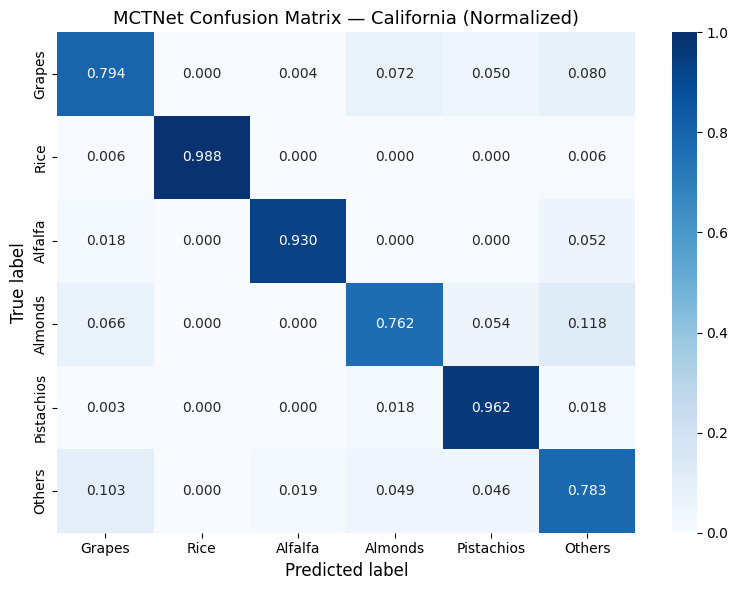


Per-Class Results — California
              precision    recall  f1-score   support

      Grapes     0.7825    0.7936    0.7880      1754
        Rice     1.0000    0.9879    0.9939      1737
     Alfalfa     0.9009    0.9303    0.9153       674
     Almonds     0.5593    0.7619    0.6450       483
  Pistachios     0.5571    0.9618    0.7055       340
      Others     0.9099    0.7830    0.8417      3212

    accuracy                         0.8470      8200
   macro avg     0.7849    0.8697    0.8149      8200
weighted avg     0.8657    0.8470    0.8513      8200

  OA:    0.8470   (paper: 0.852)
  Kappa: 0.7993   (paper: 0.806)
  F1:    0.8149   (paper: 0.829)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_predictions(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for X_batch, mask_batch, y_batch in loader:
            X_batch    = X_batch.to(device)
            mask_batch = mask_batch.to(device)

            outputs = model(X_batch, mask_batch)
            probs   = torch.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs.cpu().numpy())

    return (np.array(all_labels),
            np.array(all_preds),
            np.array(all_probs))



def plot_confusion_matrix(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)

    cm_norm = cm.astype(float)
    for i in range(len(cm)):
        row_sum = cm[i].sum()
        if row_sum > 0:
            cm_norm[i] = cm[i] / row_sum

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_norm,
        annot      = True,
        fmt        = '.3f',
        cmap       = 'Blues',
        xticklabels = class_names,
        yticklabels = class_names,
        vmin = 0, vmax = 1,
        ax   = ax
    )
    ax.set_xlabel('Predicted label', fontsize=12)
    ax.set_ylabel('True label',      fontsize=12)
    ax.set_title(title,              fontsize=13)
    plt.tight_layout()
    plt.show()

    return cm, cm_norm


def print_classification_report(labels, preds, class_names, state_name):
    print(f"\n{'='*60}")
    print(f"Per-Class Results — {state_name}")
    print(f"{'='*60}")
    print(classification_report(
        labels, preds,
        target_names = class_names,
        digits       = 4
    ))


ark_class_names = ['Corn', 'Cotton', 'Rice', 'Soybeans', 'Others']

y_true_ark, y_pred_ark, y_probs_ark = get_predictions(
    model_ark, ark_test_loader, device)

cm_ark, cm_norm_ark = plot_confusion_matrix(
    y_true_ark, y_pred_ark,
    class_names = ark_class_names,
    title       = 'MCTNet Confusion Matrix — Arkansas (Normalized)'
)

print_classification_report(
    y_true_ark, y_pred_ark,
    class_names = ark_class_names,
    state_name  = 'Arkansas'
)

from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
oa    = accuracy_score(y_true_ark, y_pred_ark)
kappa = cohen_kappa_score(y_true_ark, y_pred_ark)
f1    = f1_score(y_true_ark, y_pred_ark, average='macro', zero_division=0)

print(f"  OA:    {oa:.4f}   (paper: 0.968)")
print(f"  Kappa: {kappa:.4f}   (paper: 0.951)")
print(f"  F1:    {f1:.4f}   (paper: 0.933)")


cal_class_names = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

y_true_cal, y_pred_cal, y_probs_cal = get_predictions(
    model_cal, cal_test_loader, device)

cm_cal, cm_norm_cal = plot_confusion_matrix(
    y_true_cal, y_pred_cal,
    class_names = cal_class_names,
    title       = 'MCTNet Confusion Matrix — California (Normalized)'
)

print_classification_report(
    y_true_cal, y_pred_cal,
    class_names = cal_class_names,
    state_name  = 'California'
)

oa    = accuracy_score(y_true_cal, y_pred_cal)
kappa = cohen_kappa_score(y_true_cal, y_pred_cal)
f1    = f1_score(y_true_cal, y_pred_cal, average='macro', zero_division=0)

print(f"  OA:    {oa:.4f}   (paper: 0.852)")
print(f"  Kappa: {kappa:.4f}   (paper: 0.806)")
print(f"  F1:    {f1:.4f}   (paper: 0.829)")